In [1]:
#AUTHOR: goli :)

In [2]:
#required libraries

import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import netCDF4
from netCDF4 import Dataset
import pyresample as pr
from pyproj import Proj, CRS

In [3]:
#to save disk space, using opendap
opendap_url = 'https://thredds.met.no/thredds/dodsC/osisaf/met.no/ice/drift_lr/single_sensor/ascat-metopC/2026/02/ice_drift_nh_polstere-625_ascat-metopC_202602011200-202602031200.nc'
#data = 48 hours 2026/02/01 to 2026/02/03

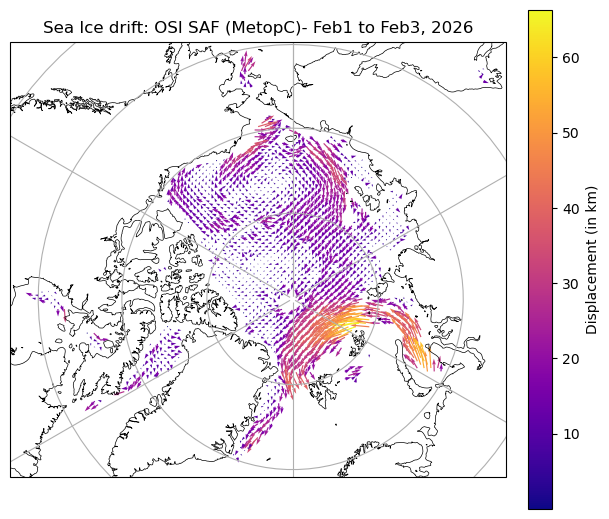

In [4]:
ds = Dataset(opendap_url,engine = 'netcdf4', decode_cf=True)

lat = ds.variables['lat'][:]   
lon = ds.variables['lon'][:]
dX = ds.variables['dX'][:]
dY = ds.variables['dY'][:]

#EUMETSAT mask recommendation
status_flag = ds.variables['status_flag'][:]

dX = np.ma.masked_where(status_flag<20, dX)
dX = np.ma.array(dX[0,:,:])
dY = np.ma.array(dY[0,:,:])

#For EASE 2.0 Grid
output_projection=ccrs.LambertAzimuthalEqualArea(central_latitude=90.0, central_longitude= 0.0)
data_projection= ccrs.Stereographic(central_latitude=90.0, central_longitude=-45.0, true_scale_latitude=70.0)

initial_points = output_projection.transform_points(ccrs.PlateCarree(), lon[~dX.mask], lat[~dY.mask])
transformed_vectors = output_projection.transform_vectors(data_projection, lon[~dX.mask], lat[~dY.mask], dX[~dX.mask], dY[~dY.mask])
displacement = np.sqrt(transformed_vectors[0]**2 + transformed_vectors[1]**2)

#extent for sd and ad
xmin = -4500000.0
ymin = -4500000.0
xmax = 4500000.0
ymax = 4500000.0
ex = [xmin,xmax,ymin,ymax]

#for 62.5 km LR (single sensor) product, change the area_definition as required
area_defnition = pr.AreaDefinition("North", "north", "north", 
                       "+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs +type=crs", 
                       144, 144, #width and height
                       (xmin, ymin, xmax, ymax))

plt.figure(figsize=(7,7))
mycrs = area_defnition.to_cartopy_crs()
ex = [xmin,xmax,ymin,ymax]
ax = plt.axes(projection=mycrs)
ax.gridlines()
ax.coastlines(linewidth=0.5, color='k', resolution='50m')
           
#map ice drift
im = ax.quiver(initial_points[:,0],initial_points[:, 1], transformed_vectors[0], transformed_vectors[1], displacement, cmap='plasma')


plt.title('Sea Ice drift: OSI SAF (MetopC)- Feb1 to Feb3, 2026')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Displacement (in km)')


Text(0.5, 1.0, 'Sea Ice Divergence (MetopC): Feb1 to 3, 2026')

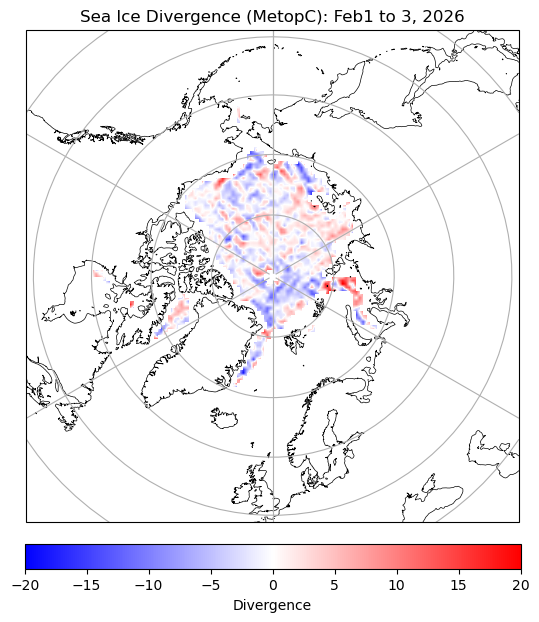

In [5]:
#to resample the divergence data
sd = pr.SwathDefinition(lons = lon[~dX.mask], lats = lat[~dY.mask])
grid_data_x = pr.kd_tree.resample_nearest(sd, transformed_vectors[0], area_defnition, radius_of_influence= 90_000, fill_value = np.nan)
grid_data_y = pr.kd_tree.resample_nearest(sd, transformed_vectors[1], area_defnition, radius_of_influence= 90_000, fill_value = np.nan)

#calculate partial derivatives of displacement components
#note: gradient returns (d_dy, d_dx) for 2D arrays if using default indexing
dpdx_dy, dpdx_dx = np.gradient(grid_data_x)
dpdy_dy, dpdy_dx = np.gradient(grid_data_y)

#sum the appropriate components to get divergence
divergence = dpdx_dx + dpdy_dy

#plotting
plt.figure(figsize= (7,7))
ax = plt.axes(projection=mycrs)

im_div = ax.imshow(divergence, extent = ex, cmap = 'bwr', vmin = -20, vmax = 20, interpolation= 'bilinear')

ax.coastlines(linewidth=0.5, color='k', resolution='50m')
ax.gridlines()
plt.colorbar(im_div,fraction=0.046, pad=0.04, orientation='horizontal', label='Divergence')

plt.title('Sea Ice Divergence (MetopC): Feb1 to 3, 2026')
